# Demo C: 3D Shepp-Logan interleaved sampling with realistic rigid motion

This example demonstrates 3D rigid motion correction using simulated random translation and rotation events. Note that the estimated rigid motion parameters may differ from the ground truth. This discrepancy arises because rotations performed about a center other than the image center introduce additional translation components. Furthermore, global shifts and rotations applied across all motion states can also contribute to these differences.

[Demo C] Loading config...
[Demo C] Initializing runtime...
[Demo C] Loading data and building operators...
[DataLoader] Reading source data (data_type=shepp-logan)...
[DataLoader] k-space normalized (rms), scale=7.879848e-02
[2026-08-28 09:16:00] [csm] slice all calculating coil sensitivity maps (method=espirit)


EspiritCalib:   0%|          | 0/10 [00:00<?, ?it/s]

[DataLoader] Starting motion simulation (type=rigid-realistic)...


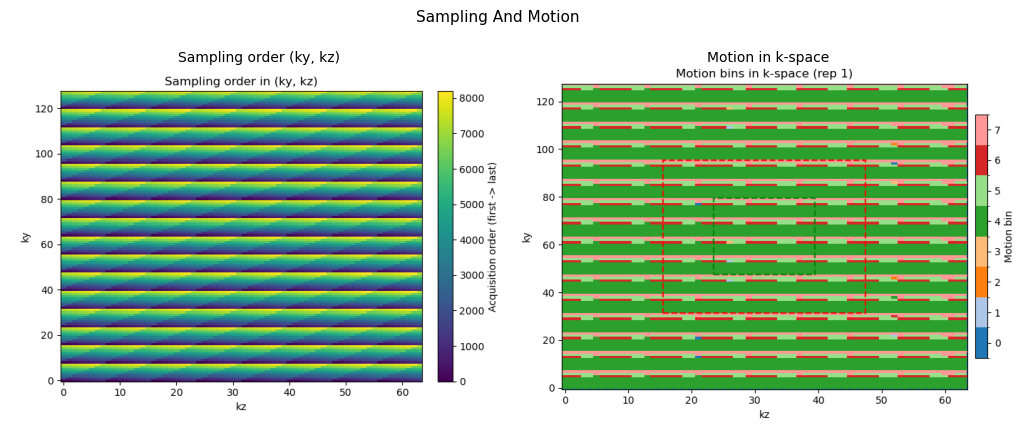

[Demo C] Starting reconstruction...


Resolution level 1/3:   0%|          | 0/10 [00:00<?, ?it/s]

Resolution level 2/3:   0%|          | 0/4 [00:00<?, ?it/s]

Resolution level 3/3:   0%|          | 0/4 [00:00<?, ?it/s]

Elapsed time: 38.51 s


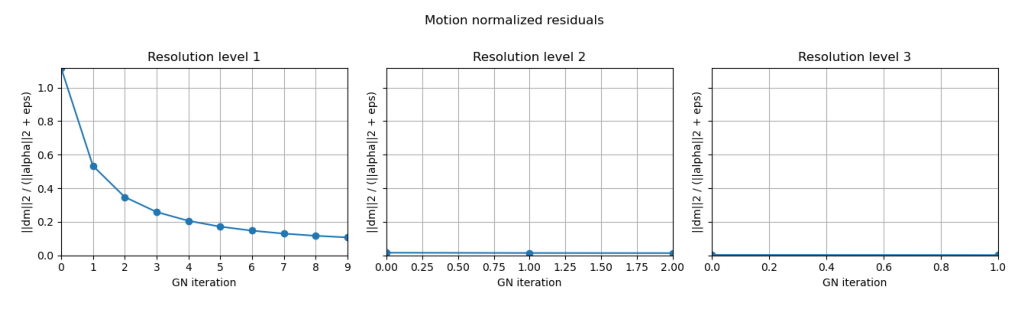

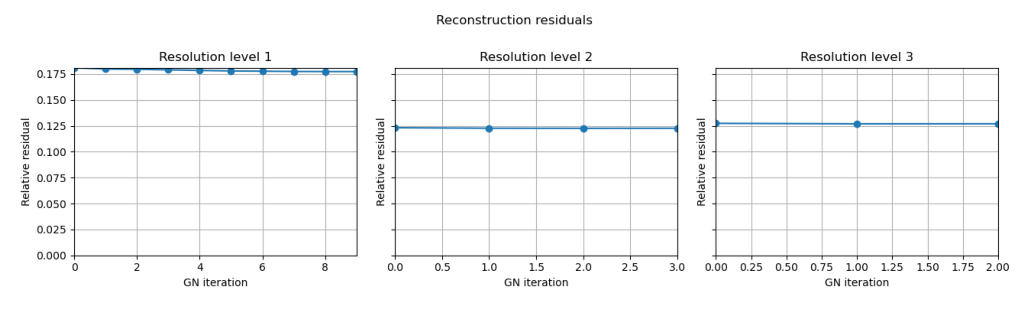

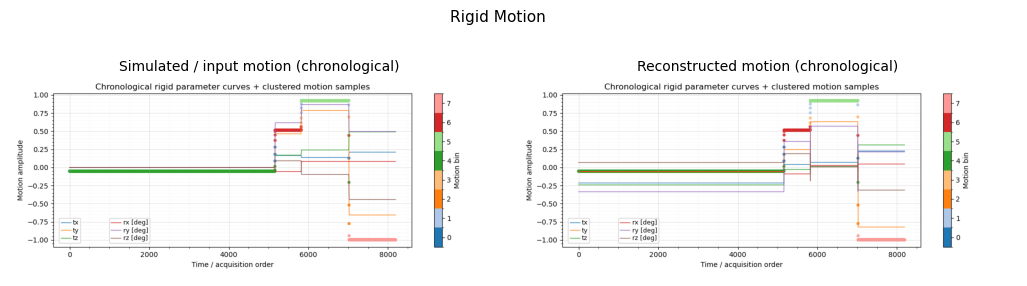

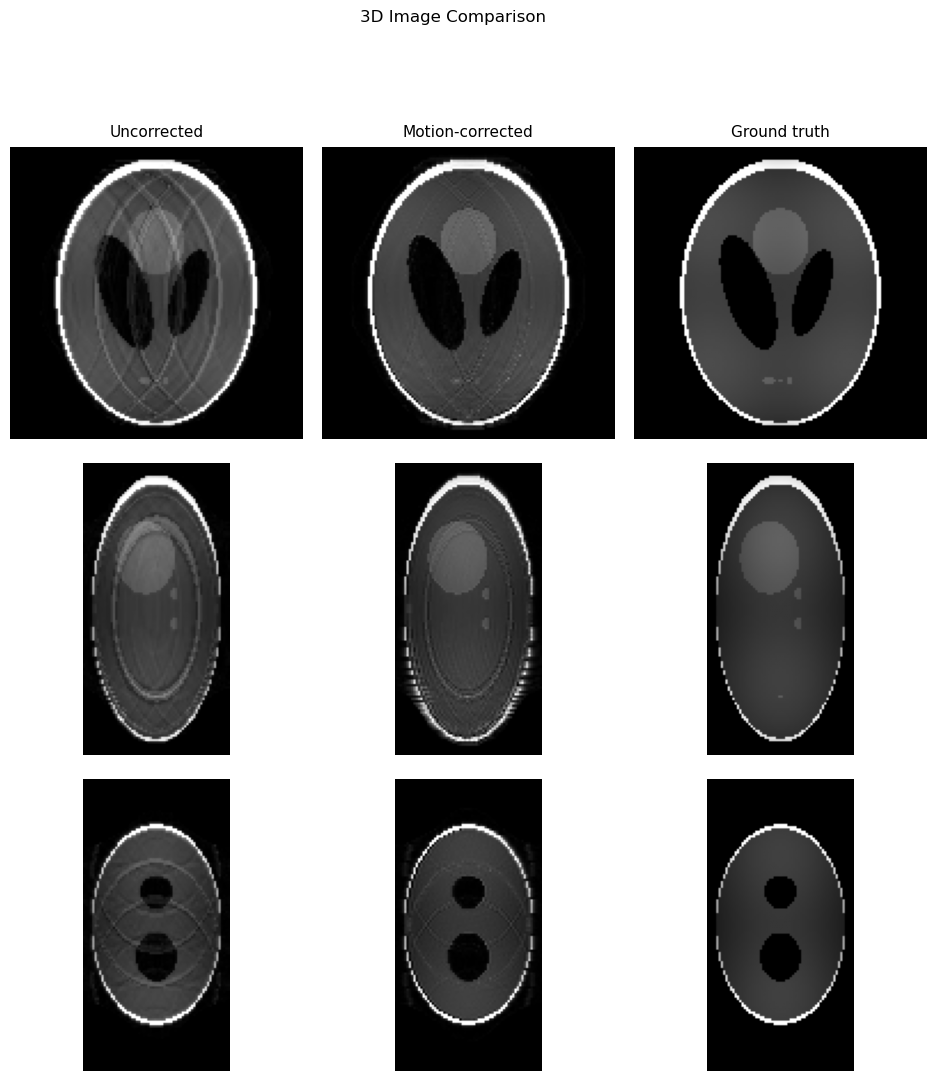

In [1]:
import time
from src.runtime.runtime_config import load_config
from src.preprocessing.DataLoader import DataLoader
from src.reconstruction.JointReconstructor import JointReconstructor
from src.runtime.runtime_setup import initialize_runtime
from src.utils.notebook_display import (
    display_input_sampling_motion_panels,
    display_logs_and_motion_same_as_2d,
    display_3d_image_matrix,
)

jupyter_notebook_flag = True
def main():
    print("[Demo C] Loading config...")
    params = load_config(
        data_type="shepp-logan",
        shepp_logan_config="config/synthetic_data/shepp_logan_3d.toml",
        reconstruction_config="config/reconstruction/rigid_3d.toml",
        sampling_config="config/sampling_simulation/interleaved.toml",
        motion_simulation_config="config/motion_simulation/rigid_3d.toml",
        simulated_motion_type="rigid-realistic",
        overrides={
            "jupyter_notebook_flag": jupyter_notebook_flag,
            "runtime_device": "gpu",
            "N_motion_states": 8,
            "coil_sensitivity_method": "espirit",
            "acs": 8,
            "kernel_width": 4,
            "espirit_max_iter": 10,
        },
    )

    print("[Demo C] Initializing runtime...")
    sp_device, t_device = initialize_runtime(params)

    print("[Demo C] Loading data and building operators...")
    data = DataLoader(params=params, t_device=t_device, sp_device=sp_device)
    display_input_sampling_motion_panels(params)

    print("[Demo C] Starting reconstruction...")
    recon = JointReconstructor(
        data.kspace,
        data.smaps,
        data.sampling_idx,
        motion_signal=data.motion_signal,
        params=params,
        motion_plot_context=data.motion_plot_context,
    )
    t0 = time.time()
    image_joint, _ = recon.run()
    print(f"Elapsed time: {time.time() - t0:.2f} s")

    display_logs_and_motion_same_as_2d(params)

    display_3d_image_matrix(
        image_uncorrected=data.image_no_moco[0],
        image_corrected=image_joint[0],
        image_gt=data.image_ground_truth[0],
    )


if __name__ == "__main__":
    main()
